In [2]:
"""
PEFT_Sentiment_Analysis_on_Movie_Reviews
Example Notebook (End-to-End Pipeline)

This notebook demonstrates how to:
1. Load the Fake/True dataset
2. Preprocess text (punctuation removal, tokenization, stopwords, lemmatization)
3. Convert into HuggingFace Dataset
4. Tokenize with RoBERTa
5. Load base RoBERTa model
6. Apply LoRA (PEFT)
7. Train using HuggingFace Trainer
8. Evaluate using accuracy, precision, recall, F1, AUC
9. Visualize confusion matrix
10. Explain predictions using SHAP

All heavy logic is imported from PEFT_Sentiment_Analysis_on_Movie_Reviews_utils.py
"""


'\nPEFT_Sentiment_Analysis_on_Movie_Reviews\nExample Notebook (End-to-End Pipeline)\n\nThis notebook demonstrates how to:\n1. Load the Fake/True dataset\n2. Preprocess text (punctuation removal, tokenization, stopwords, lemmatization)\n3. Convert into HuggingFace Dataset\n4. Tokenize with RoBERTa\n5. Load base RoBERTa model\n6. Apply LoRA (PEFT)\n7. Train using HuggingFace Trainer\n8. Evaluate using accuracy, precision, recall, F1, AUC\n9. Visualize confusion matrix\n10. Explain predictions using SHAP\n\nAll heavy logic is imported from PEFT_Sentiment_Analysis_on_Movie_Reviews_utils.py\n'

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PEFT_Sentiment_Analysis_utils import (
    load_fake_true,
    preprocess_text,
    split_data,
    prepare_hf_dataset,
    load_roberta_lora,
    get_training_args,
    get_trainer,
    evaluate_model,
    setup_shap,
    shap_explain
)


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load Fake + True dataset
df = load_fake_true("/Users/vikas/src/umd_classes1/class_project/MSML610/Fall2025/Projects/UmdTask96_Fall2025_PEFT_Sentiment_Analysis_on_Movie_Reviews/Data/Fake.csv", "/Users/vikas/src/umd_classes1/class_project/MSML610/Fall2025/Projects/UmdTask96_Fall2025_PEFT_Sentiment_Analysis_on_Movie_Reviews/Data/True.csv")

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [5]:
df = preprocess_text(df)
df[["text", "text_final"]].head()


,text,text_final
0,Donald Trump just couldn t wish all Americans ...,donald trump wish american happy new year leav...
1,House Intelligence Committee Chairman Devin Nu...,house intelligence committee chairman devin nu...
2,"On Friday, it was revealed that former Milwauk...",friday revealed former milwaukee sheriff david...
3,"On Christmas day, Donald Trump announced that ...",christmas day donald trump announced would bac...
4,Pope Francis used his annual Christmas Day mes...,pope francis used annual christmas day message...


In [6]:
train_texts, test_texts, train_labels, test_labels = split_data(df)

print("Train size:", len(train_texts))
print("Test size:", len(test_texts))


Train size: 35918
Test size: 8980


In [ ]:
train_dataset, test_dataset, tokenizer = prepare_hf_dataset(
    train_texts, test_texts, train_labels, test_labels
)

train_dataset, test_dataset


Map:   0%|          | 0/35918 [00:00<?, ? examples/s]

In [ ]:
model = load_roberta_lora()


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


In [ ]:
training_args = get_training_args()
trainer = get_trainer(model, train_dataset, test_dataset, training_args)


In [ ]:
trainer.train()


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
50,0.688600
100,0.593700
150,0.226700
200,0.090700
250,0.107200
300,0.139300
350,0.138800
400,0.078600
450,0.050500
500,0.049400


TrainOutput(global_step=800, training_loss=0.1573331695795059, metrics={'train_runtime': 1745.2043, 'train_samples_per_second': 3.667, 'train_steps_per_second': 0.458, 'total_flos': 850675354828800.0, 'train_loss': 0.1573331695795059, 'epoch': 0.17817371937639198})

In [ ]:
metrics = evaluate_model(trainer, test_dataset, test_labels)

print("Accuracy :", metrics["accuracy"])
print("Precision:", metrics["precision"])
print("Recall   :", metrics["recall"])
print("F1-score :", metrics["f1"])
print("AUC-ROC  :", metrics["roc_auc"])

print("\nClassification Report:\n")
print(metrics["classification_report"])


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Accuracy : 0.9791759465478842
Precision: 0.9914977109221713
Recall   : 0.9684838160136287
F1-score : 0.9798556501131099
AUC-ROC  : 0.9983810744627208

Classification Report:

              precision    recall  f1-score   support

           0     0.9663    0.9909    0.9784      4284
           1     0.9915    0.9685    0.9799      4696

    accuracy                         0.9792      8980
   macro avg     0.9789    0.9797    0.9792      8980
weighted avg     0.9795    0.9792    0.9792      8980



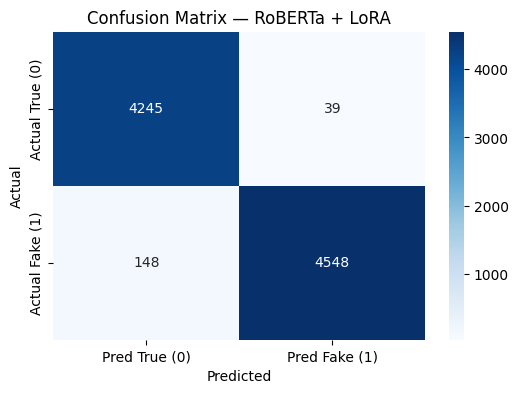

In [ ]:
cm = metrics["confusion_matrix"]

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred True (0)", "Pred Fake (1)"],
    yticklabels=["Actual True (0)", "Actual Fake (1)"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — RoBERTa + LoRA")
plt.show()


SECTION 10 — SHAP Explainability (Short Snippet)

In [ ]:
import shap

# 1️⃣ Pick a short text snippet for clean visualization
raw_text = df["text"].iloc[0]   # full article
short_snippet = " ".join(raw_text.split(" ")[:40])  # first 40 words

print("Short Snippet for SHAP:")
print(short_snippet)



Short Snippet for SHAP:
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former


In [ ]:
# Create classifier pipeline for SHAP
explainer = setup_shap(model, tokenizer)

# Compute SHAP values for the short snippet
shap_values = shap_explain(explainer, short_snippet)

# Visualize
shap.plots.text(shap_values[0])


Device set to use mps:0
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
PartitionExplainer explainer: 2it [00:21, 21.68s/it]               


In [ ]:
%pip install lime --quiet
from lime.lime_text import LimeTextExplainer
import numpy as np


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Force model to CPU for LIME (required on Apple Silicon)
model.to("cpu")

def lime_predict(texts):
    outputs = []
    for t in texts:
        enc = tokenizer(
            t,
            padding="max_length",
            truncation=True,
            max_length=256,
            return_tensors="pt"
        )
        logits = model(**enc).logits.detach().numpy()[0]
        probs = np.exp(logits) / np.exp(logits).sum()
        outputs.append(probs)
    return np.array(outputs)


In [ ]:
from IPython.display import HTML, display

explainer_lime = LimeTextExplainer(class_names=["True News", "Fake News"])

full_article = df["text"].iloc[0]   # complete raw article, not cleaned

exp = explainer_lime.explain_instance(
    full_article,
    lime_predict,
    num_features=10,        # top words
    top_labels=1            # only the predicted label
)

display(HTML(exp.as_html()))


NameError: name 'LimeTextExplainer' is not defined